<a href="https://colab.research.google.com/github/tun784/AI/blob/main/Lab6-bai4_bai5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Bài 4**

In [ ]:
from google.colab import files
uploaded = files.upload()

In [4]:
!pip install -q tensorflow keras opencv-python matplotlib seaborn scikit-learn
!pip list

Package                               Version
------------------------------------- -------------------
absl-py                               1.4.0
accelerate                            1.7.0
aiofiles                              24.1.0
aiohappyeyeballs                      2.6.1
aiohttp                               3.11.15
aiosignal                             1.3.2
alabaster                             1.0.0
albucore                              0.0.24
albumentations                        2.0.8
ale-py                                0.11.1
altair                                5.5.0
annotated-types                       0.7.0
antlr4-python3-runtime                4.9.3
anyio                                 4.9.0
argon2-cffi                           23.1.0
argon2-cffi-bindings                  21.2.0
array_record                          0.7.2
arviz                                 0.21.0
astropy                               7.1.0
astropy-iers-data                     0.2025.5.26.0.

In [7]:
# Import các thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

# Kiểm tra phiên bản TensorFlow
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.18.0


Số ảnh Nam: 155
Số ảnh Nữ: 89
Đang tải ảnh Nam...
Đang tải ảnh Nữ...
Tổng số ảnh: 244
Kích thước ảnh: (128, 128, 3)
Phân bố nhãn: Nam=155, Nữ=89


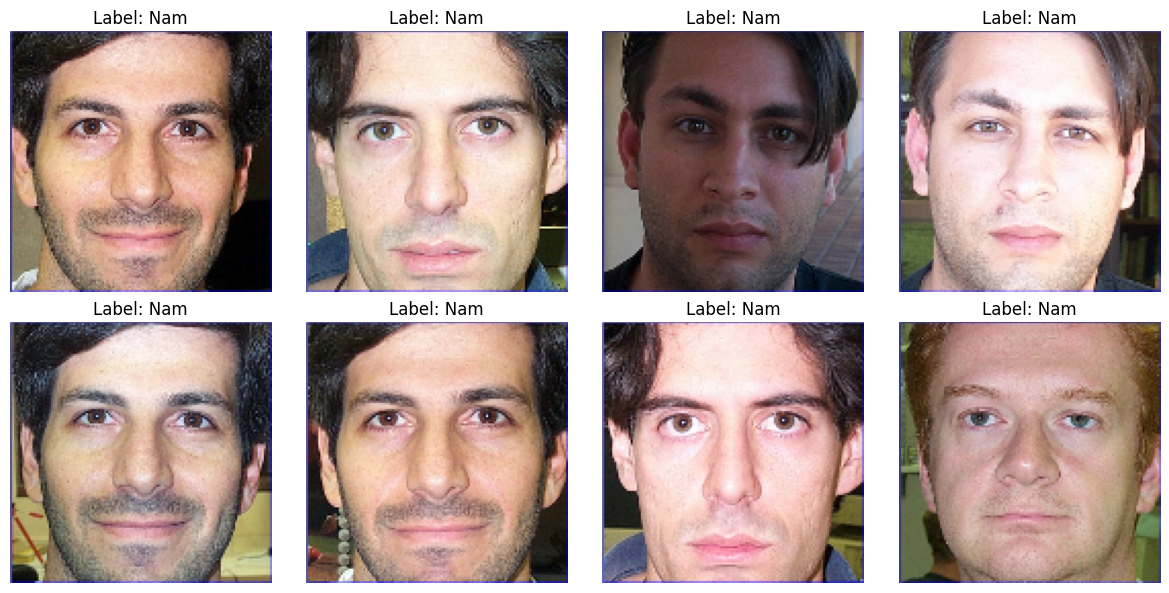

Chuyển đổi ảnh thành sequences...
Kích thước sequences: (244, 8, 6144)
Training set: (195, 8, 6144)
Test set: (49, 8, 6144)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 8, 128)         │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 8, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,277,858 (12.50 MB)

 Trainable params: 3,277,858 (12.50 MB)

 Non-trainable params: 0 (0.00 B)

Bắt đầu huấn luyện mô hình...
Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.5441 - loss: 0.6893 - val_accuracy: 0.6327 - val_loss: 0.6676 - learning_rate: 0.0010
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6028 - loss: 0.6587 - val_accuracy: 0.6327 - val_loss: 0.6568 - learning_rate: 0.0010
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6063 - loss: 0.6646 - val_accuracy: 0.6327 - val_loss: 0.6675 - learning_rate: 0.0010
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5880 - loss: 0.6879 - val_accuracy: 0.6327 - val_loss: 0.6746 - learning_rate: 0.0010
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5680 - loss: 0.6840 - val_accuracy: 0.6327 - val_loss: 0.6712 - learning_rate: 0.0010
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6206 - loss: 0.6510 - val_accuracy: 0.6327 - val_loss: 0.6562 - learning_rate: 5.0000e-04
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6176 - l

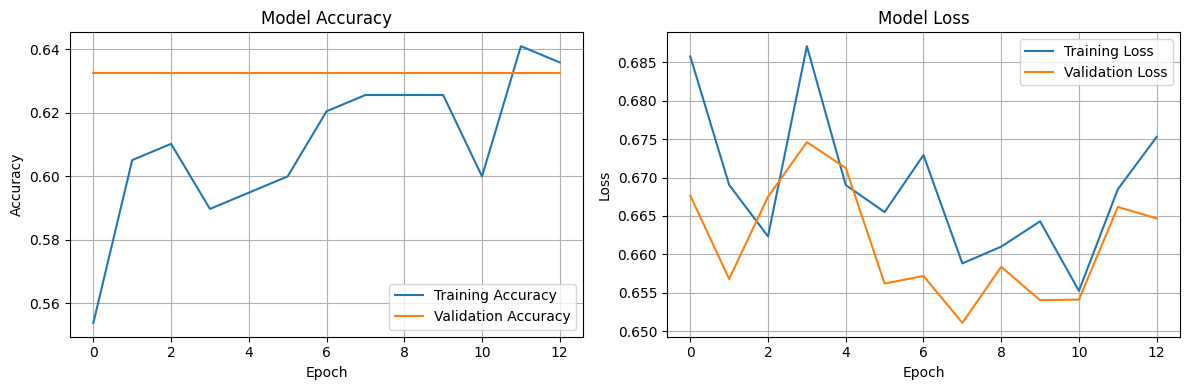


Đánh giá mô hình trên tập test:
Test Accuracy: 0.6327
Test Loss: 0.6605
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 345ms/step

Classification Report:
              precision    recall  f1-score   support

         Nam       0.63      1.00      0.78        31
          Nữ       0.00      0.00      0.00        18

    accuracy                           0.63        49
   macro avg       0.32      0.50      0.39        49
weighted avg       0.40      0.63      0.49        49



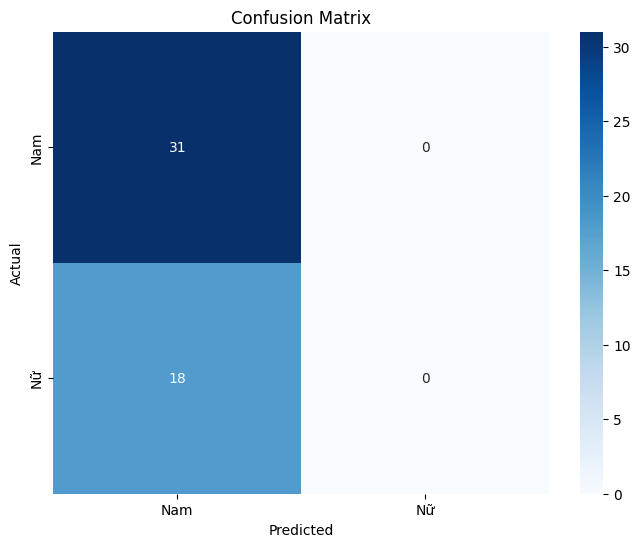

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')
# Thiết lập GPU nếu có

# Định nghĩa các tham số
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 20
SEQUENCE_LENGTH = 8  # Chia ảnh thành 8 phần để tạo sequence cho LSTM

BASE_PATH = '/content/sample_data'
MALE_PATH = os.path.join(BASE_PATH, 'Male')
FEMALE_PATH = os.path.join(BASE_PATH, 'Female')

# Kiểm tra xem thư mục dữ liệu có tồn tại không
if os.path.exists(MALE_PATH) and os.path.exists(FEMALE_PATH):
    print(f"Số ảnh Nam: {len(os.listdir(MALE_PATH))}")
    print(f"Số ảnh Nữ: {len(os.listdir(FEMALE_PATH))}")
else:
    print("Vui lòng kiểm tra lại đường dẫn dữ liệu!")
    print("Cần có thư mục 'Male' và 'Female' chứa ảnh tương ứng")

# Hàm tải và tiền xử lý dữ liệu
def load_and_preprocess_data(male_path, female_path, img_size=IMG_SIZE):
  """
  Tải và tiền xử lý dữ liệu ảnh
  """
  images = []
  labels = []

  # Tải ảnh nam (label = 0)
  print("Đang tải ảnh Nam...")
  for filename in os.listdir(male_path):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
      img_path = os.path.join(male_path, filename)
      try:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        img = img.astype('float32') / 255.0
        images.append(img)
        labels.append(0)  # Nam = 0
      except Exception as e:
        print(f"Lỗi khi tải ảnh {filename}: {e}")

  # Tải ảnh nữ (label = 1)
  print("Đang tải ảnh Nữ...")
  for filename in os.listdir(female_path):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
      img_path = os.path.join(female_path, filename)
      try:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        img = img.astype('float32') / 255.0
        images.append(img)
        labels.append(1)  # Nữ = 1
      except Exception as e:
        print(f"Lỗi khi tải ảnh {filename}: {e}")

  return np.array(images), np.array(labels)

# Hàm chuyển đổi ảnh thành sequence cho LSTM
def create_sequences(images, sequence_length=SEQUENCE_LENGTH):
  """
  Chuyển đổi ảnh thành sequence bằng cách chia ảnh thành các phần
  """
  sequences = []

  for img in images:
    # Chia ảnh thành các dải ngang (horizontal strips)
    height = img.shape[0]
    strip_height = height // sequence_length

    sequence = []
    for i in range(sequence_length):
      start_row = i * strip_height
      end_row = (i + 1) * strip_height if i < sequence_length - 1 else height
      strip = img[start_row:end_row, :, :]
      # Flatten strip để tạo vector features
      strip_flattened = strip.flatten()
      sequence.append(strip_flattened)

    sequences.append(sequence)

  return np.array(sequences)

# Tải dữ liệu
try:
  X, y = load_and_preprocess_data(MALE_PATH, FEMALE_PATH)
  print(f"Tổng số ảnh: {len(X)}")
  print(f"Kích thước ảnh: {X[0].shape}")
  print(f"Phân bố nhãn: Nam={np.sum(y==0)}, Nữ={np.sum(y==1)}")
except Exception as e:
  print(f"Lỗi khi tải dữ liệu: {e}")
  # Tạo dữ liệu mẫu nếu không tải được dữ liệu thật
  print("Tạo dữ liệu mẫu để demo...")
  X = np.random.rand(1000, IMG_SIZE, IMG_SIZE, 3).astype('float32')
  y = np.random.randint(0, 2, 1000)

# Hiển thị một số ảnh mẫu
def display_sample_images(images, labels, num_samples=8):
  """
  Hiển thị một số ảnh mẫu
  """
  fig, axes = plt.subplots(2, 4, figsize=(12, 6))
  axes = axes.ravel()

  for i in range(min(num_samples, len(images))):
    axes[i].imshow(images[i])
    label_text = "Nam" if labels[i] == 0 else "Nữ"
    axes[i].set_title(f'Label: {label_text}')
    axes[i].axis('off')

  plt.tight_layout()
  plt.show()

# Hiển thị ảnh mẫu
display_sample_images(X, y)

# Chuyển đổi ảnh thành sequences
print("Chuyển đổi ảnh thành sequences...")
X_sequences = create_sequences(X)
print(f"Kích thước sequences: {X_sequences.shape}")

# Chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(
  X_sequences, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Chuyển đổi labels thành categorical
y_train_cat = to_categorical(y_train, 2)
y_test_cat = to_categorical(y_test, 2)

# Xây dựng mô hình LSTM
def build_lstm_model(input_shape, num_classes=2):
  """
  Xây dựng mô hình LSTM cho phân loại ảnh
  """
  model = keras.Sequential([
    # Input layer
    layers.Input(shape=input_shape),

    # LSTM layers
    layers.LSTM(128, return_sequences=True, dropout=0.3),
    layers.LSTM(64, return_sequences=True, dropout=0.3),
    layers.LSTM(32, dropout=0.3),

    # Dense layers
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),

    # Output layer
    layers.Dense(num_classes, activation='softmax')
  ])

  return model

# Tạo mô hình
input_shape = (SEQUENCE_LENGTH, X_train.shape[2])
model = build_lstm_model(input_shape)

# Hiển thị cấu trúc mô hình
model.summary()

# Compile mô hình
model.compile(
  optimizer='adam',
  loss='categorical_crossentropy',
  metrics=['accuracy']
)

# Định nghĩa callbacks
callbacks = [
  keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
  ),
  keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7
  )
]

# Huấn luyện mô hình
print("Bắt đầu huấn luyện mô hình...")
history = model.fit(
  X_train, y_train_cat,
  batch_size=BATCH_SIZE,
  epochs=EPOCHS,
  validation_data=(X_test, y_test_cat),
  callbacks=callbacks,
  verbose=1
)

# Vẽ biểu đồ training history
def plot_training_history(history):
  """
  Vẽ biểu đồ quá trình huấn luyện
  """
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

  # Accuracy
  ax1.plot(history.history['accuracy'], label='Training Accuracy')
  ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
  ax1.set_title('Model Accuracy')
  ax1.set_xlabel('Epoch')
  ax1.set_ylabel('Accuracy')
  ax1.legend()
  ax1.grid(True)

  # Loss
  ax2.plot(history.history['loss'], label='Training Loss')
  ax2.plot(history.history['val_loss'], label='Validation Loss')
  ax2.set_title('Model Loss')
  ax2.set_xlabel('Epoch')
  ax2.set_ylabel('Loss')
  ax2.legend()
  ax2.grid(True)

  plt.tight_layout()
  plt.show()

# Vẽ biểu đồ training history
plot_training_history(history)

# Đánh giá mô hình
print("\nĐánh giá mô hình trên tập test:")
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Dự đoán và tạo confusion matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=['Nam', 'Nữ']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nam', 'Nữ'], yticklabels=['Nam', 'Nữ'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Hàm dự đoán cho ảnh mới
def predict_gender(model, image_path):
  """
  Dự đoán giới tính cho một ảnh mới
  """
  try:
    # Tải và tiền xử lý ảnh
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype('float32') / 255.0

    # Chuyển đổi thành sequence
    img_sequence = create_sequences(np.array([img]))

    # Dự đoán
    prediction = model.predict(img_sequence)
    predicted_class = np.argmax(prediction, axis=1)[0]
    confidence = np.max(prediction)

    gender = "Nam" if predicted_class == 0 else "Nữ"

    # Hiển thị kết quả
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f'Dự đoán: {gender} (Confidence: {confidence:.2f})')
    plt.axis('off')
    plt.show()

    return gender, confidence

  except Exception as e:
    print(f"Lỗi khi dự đoán: {e}")
    return None, None

**Bài 5**

In [5]:
from google.colab import files
uploaded = files.upload()

Saving truyen_kieu.txt to truyen_kieu.txt


In [11]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.utils import to_categorical
import random

# Đọc nội dung tập tin Truyện Kiều
with open('truyenkieu.txt', 'r', encoding='utf-8') as f:
  text = f.read().lower()

print(f"Độ dài văn bản: {len(text)} ký tự")

# Tạo tập ký tự riêng biệt
chars = sorted(list(set(text)))
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

# Tạo dữ liệu huấn luyện (X, y)
seq_length = 40
step = 3
sentences = []
next_chars = []

for i in range(0, len(text) - seq_length, step):
  sentences.append([char_to_idx[c] for c in text[i: i + seq_length]])
  next_chars.append(char_to_idx[text[i + seq_length]])

X = to_categorical(sentences, num_classes=len(chars))
y = to_categorical(next_chars, num_classes=len(chars))

model = Sequential()
model.add(Input(shape=(seq_length, len(chars))))
model.add(LSTM(128))
model.add(Dense(len(chars), activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam')
model.summary()

model.fit(X, y, batch_size=128, epochs=20)

def sample(preds, temperature=1.0):
  preds = np.asarray(preds).astype('float64')
  preds = np.log(preds + 1e-8) / temperature
  exp_preds = np.exp(preds)
  preds = exp_preds / np.sum(exp_preds)
  probas = np.random.multinomial(1, preds, 1)
  return np.argmax(probas)

start_index = random.randint(0, len(text) - seq_length - 1)
seed = text[start_index: start_index + seq_length]
generated = seed

print("\nSeed bắt đầu:\n", seed)
print("\n=== Văn bản sinh ra ===\n")

for i in range(400):
  x_pred = np.zeros((1, seq_length, len(chars)))
  for t, char in enumerate(seed):
    x_pred[0, t, char_to_idx[char]] = 1.0

  preds = model.predict(x_pred, verbose=0)[0]
  next_index = sample(preds, temperature=0.7)
  next_char = idx_to_char[next_index]

  generated += next_char
  seed = seed[1:] + next_char

print(generated)

Độ dài văn bản: 108712 ký tự


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,148 (508.39 KB)

 Trainable params: 130,148 (508.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 3.5307
Epoch 2/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.7132
Epoch 3/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.3041
Epoch 4/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.1389
Epoch 5/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2.0420
Epoch 6/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.9722
Epoch 7/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.9276
Epoch 8/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8906
Epoch 9/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.8842
Epoch 10/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.8405
Epoch 11/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8439
Epoch 12/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.8137
Epoch 13/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.7862
Epoch 14/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.7774
Epoch 15/20
283/283 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - lo